In [212]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

(1058, 736, 3)


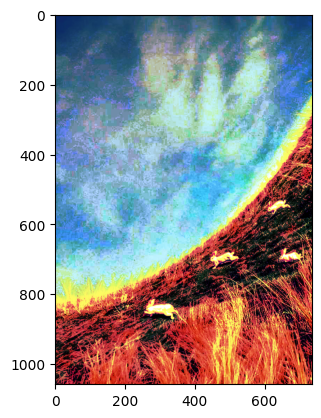

In [213]:
background = cv.imread("Assets/background.png")

plt.imshow(background)
print(background.shape)

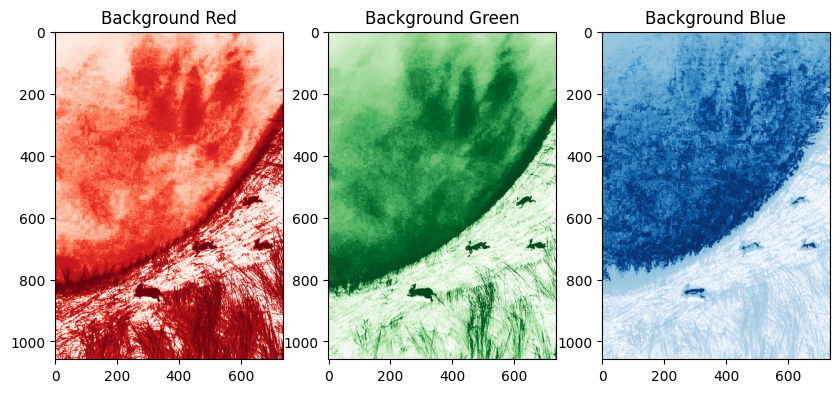

In [214]:
bgRed = background[:,:,0]
bgGreen = background[:,:,1]
bgBlue = background[:,:,2]

plt.figure(figsize=(10, 10))

plt.subplot(1, 3, 1)
plt.imshow(bgRed, cmap='Reds')
plt.title("Background Red")

plt.subplot(1, 3, 2)
plt.imshow(bgGreen, cmap='Greens')
plt.title("Background Green")

plt.subplot(1, 3, 3)
plt.imshow(bgBlue, cmap='Blues')
plt.title("Background Blue")

plt.show()

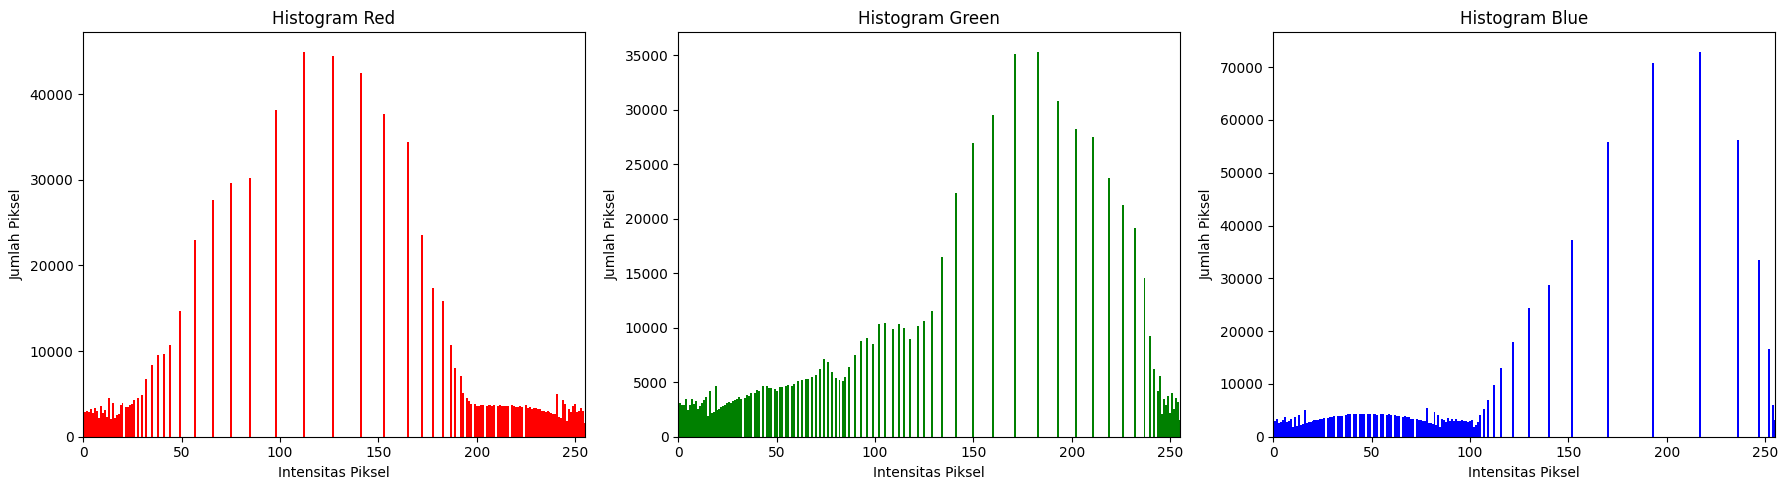

In [215]:
def hitung_histogram(gambar):
    hist = [0] * 256
    for baris in gambar:
        for px in baris:
            hist[int(px)] += 1
    return hist

histRed = hitung_histogram(bgRed)
histGreen = hitung_histogram(bgGreen)
histBlue = hitung_histogram(bgBlue)

plt.figure(figsize=(18,5))

plt.subplot(1, 3, 1)
plt.bar(range(256), histRed, color='red', width=1)
plt.title('Histogram Red')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim([0,255])

plt.subplot(1, 3, 2)
plt.bar(range(256), histGreen, color='green', width=1)
plt.title('Histogram Green')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim([0,255])

plt.subplot(1, 3, 3)
plt.bar(range(256), histBlue, color='blue', width=1)
plt.title('Histogram Blue')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim([0,255])

plt.tight_layout()
plt.show()

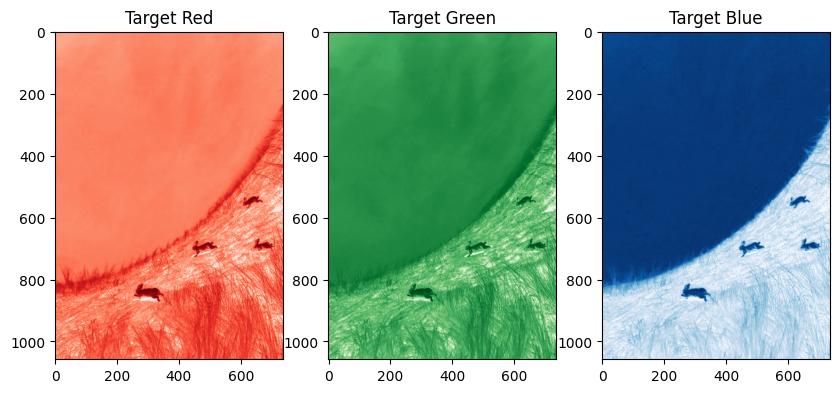

In [216]:
red_target = cv.imread("Assets/red_target.png")
green_target = cv.imread("Assets/green_target.png")
blue_target = cv.imread("Assets/blue_target.png")

red_target_gray = cv.cvtColor(red_target, cv.COLOR_BGR2GRAY)
green_target_gray = cv.cvtColor(green_target, cv.COLOR_BGR2GRAY)
blue_target_gray = cv.cvtColor(blue_target, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 10))

plt.subplot(1, 3, 1)
plt.imshow(red_target_gray, cmap='Reds')
plt.title("Target Red")

plt.subplot(1, 3, 2)
plt.imshow(green_target_gray, cmap='Greens')
plt.title("Target Green")

plt.subplot(1, 3, 3)
plt.imshow(blue_target_gray, cmap='Blues')
plt.title("Target Blue")

plt.show()

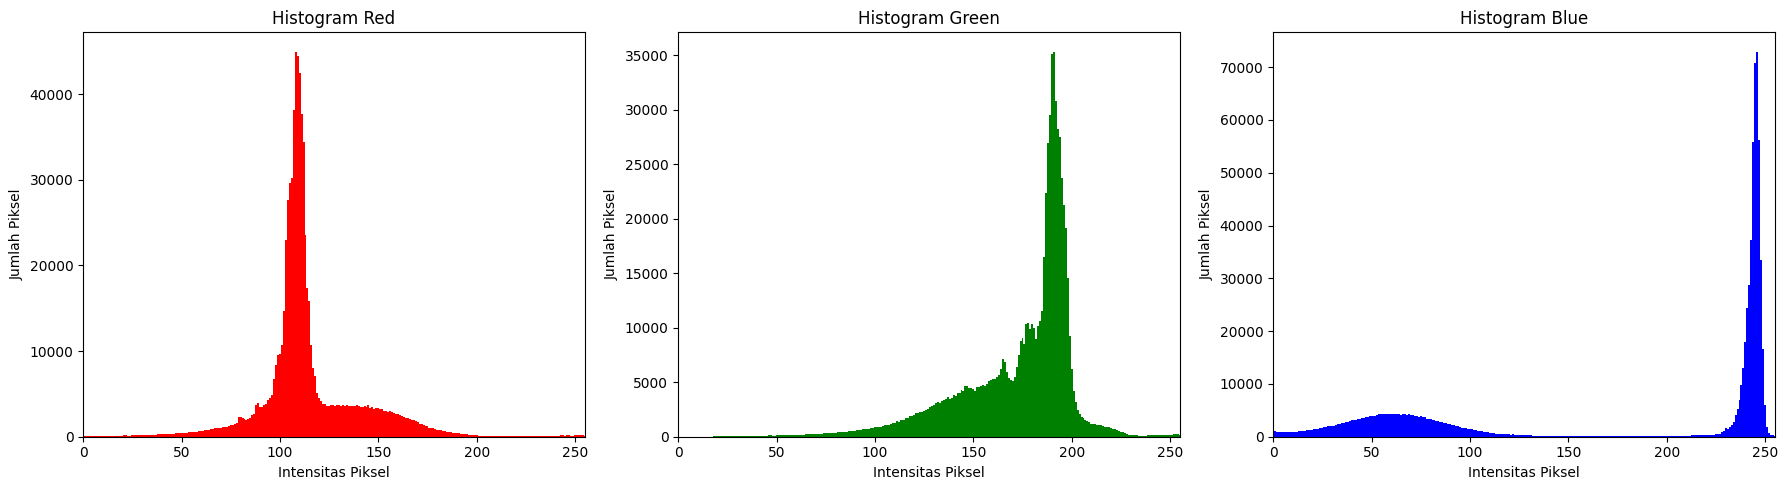

In [217]:
histRed_target = hitung_histogram(red_target_gray)
histGreen_target = hitung_histogram(green_target_gray)
histBlue_target = hitung_histogram(blue_target_gray)

plt.figure(figsize=(18,5))

plt.subplot(1, 3, 1)
plt.bar(range(256), histRed_target, color='red', width=1)
plt.title('Histogram Red')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim([0,255])

plt.subplot(1, 3, 2)
plt.bar(range(256), histGreen_target, color='green', width=1)
plt.title('Histogram Green')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim([0,255])

plt.subplot(1, 3, 3)
plt.bar(range(256), histBlue_target, color='blue', width=1)
plt.title('Histogram Blue')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim([0,255])

plt.tight_layout()
plt.show()

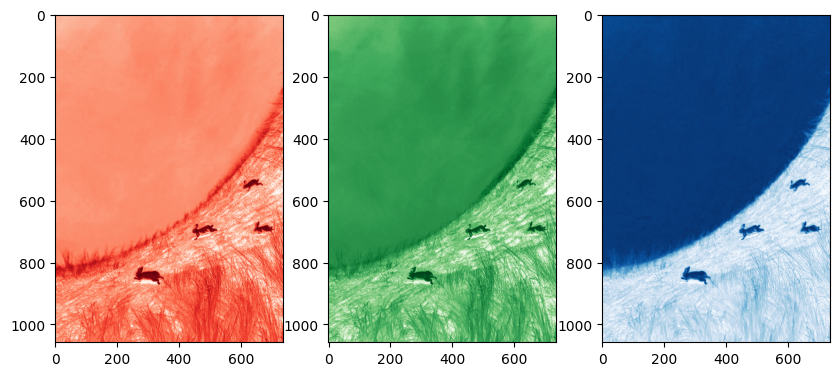

In [218]:
def spesifikasi(citra_asal, citra_target):
    
    hist_asal = np.zeros(256, dtype=int)
    hist_target = np.zeros(256, dtype=int)

    tinggi_asal, lebar_asal = citra_asal.shape
    tinggi_target, lebar_target = citra_target.shape

    for i in range(tinggi_asal):
        for j in range(lebar_asal):
            nilai = citra_asal[i, j]
            hist_asal[nilai] += 1  #menghitung kemunculan intensitas 

    for i in range(tinggi_target):
        for j in range(lebar_target):
            nilai = citra_target[i, j]
            hist_target[nilai] += 1

    cdf_asal = np.zeros(256, dtype=float)
    cdf_target = np.zeros(256, dtype=float)

    cdf_asal[0] = hist_asal[0]
    cdf_target[0] = hist_target[0]

    for i in range(1, 256):
        cdf_asal[i] = cdf_asal[i - 1] + hist_asal[i] 
        cdf_target[i] = cdf_target[i - 1] + hist_target[i]

    cdf_asal = cdf_asal / cdf_asal[-1] #normalisasi cdf menjadi rentan 0-1
    cdf_target = cdf_target / cdf_target[-1]

    map_hist = np.zeros(256, dtype=np.uint8)

    for i in range(256):
        selisih_terkecil = abs(cdf_asal[i] - cdf_target[0]) #abs = nilai slalu +
        indeks = 0

        for j in range(1, 256):
            selisih = abs(cdf_asal[i] - cdf_target[j])

            if selisih < selisih_terkecil:
                selisih_terkecil = selisih
                indeks = j

        map_hist[i] = indeks

    hasil = np.zeros((tinggi_asal, lebar_asal), dtype=np.uint8)

    for i in range(tinggi_asal):
        for j in range(lebar_asal):
            hasil[i, j] = map_hist[citra_asal[i, j]]

    return hasil

spesifikasiRed = spesifikasi(bgRed, red_target_gray)
spesifikasiGreen = spesifikasi(bgGreen, green_target_gray)
spesifikasiBlue = spesifikasi(bgBlue, blue_target_gray)

plt.figure(figsize=(10, 10))

plt.subplot(1, 3, 1)
plt.imshow(spesifikasiRed, cmap='Reds')

plt.subplot(1, 3, 2)
plt.imshow(spesifikasiGreen, cmap='Greens')

plt.subplot(1, 3, 3)
plt.imshow(spesifikasiBlue, cmap='Blues')

plt.show()

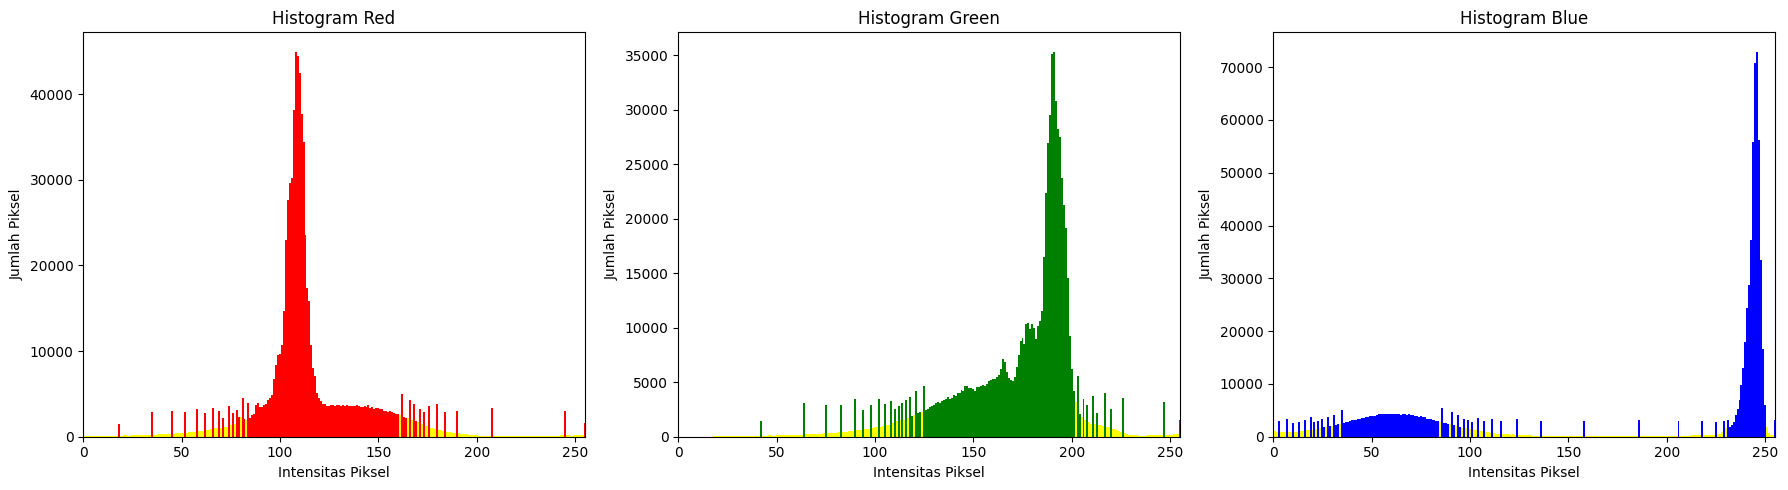

In [219]:
histSpeRed = hitung_histogram(spesifikasiRed)
histSpeGreen = hitung_histogram(spesifikasiGreen)
histSpeBlue = hitung_histogram(spesifikasiBlue)

plt.figure(figsize=(18,5))

plt.subplot(1, 3, 1)
plt.bar(range(256), histRed_target, color='yellow', width=1)
plt.bar(range(256), histSpeRed, color='red', width=1)
plt.title('Histogram Red')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim([0,255])

plt.subplot(1, 3, 2)
plt.bar(range(256), histGreen_target, color='yellow', width=1)
plt.bar(range(256), histSpeGreen, color='green', width=1)
plt.title('Histogram Green')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim([0,255])

plt.subplot(1, 3, 3)
plt.bar(range(256), histBlue_target, color='yellow', width=1)
plt.bar(range(256), histSpeBlue, color='blue', width=1)
plt.title('Histogram Blue')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim([0,255])

plt.tight_layout()
plt.show()

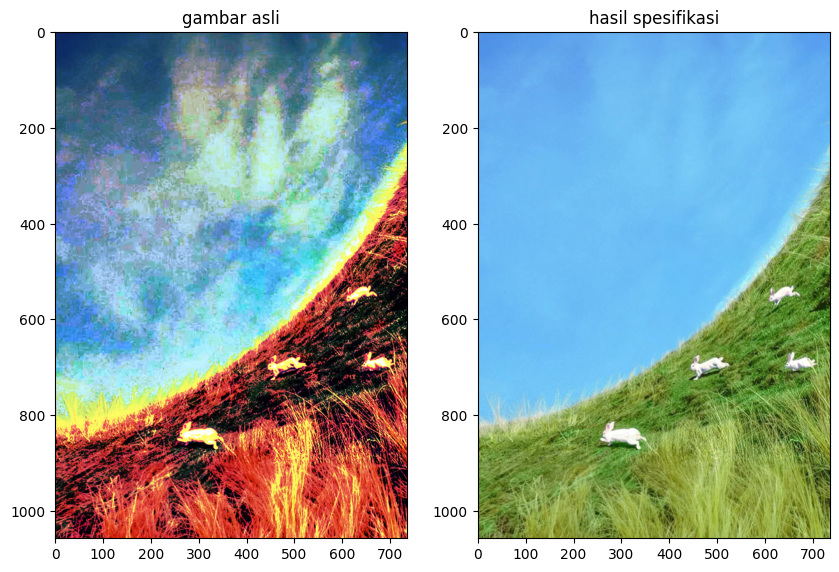

In [220]:
tinggi = spesifikasiRed.shape[0]
lebar = spesifikasiRed.shape[1]

hasil = np.zeros((tinggi, lebar, 3), dtype=np.uint8)

for i in range(tinggi):
    for j in range(lebar):

        hasil[i, j, 0] = spesifikasiBlue[i, j]
        hasil[i, j, 1] = spesifikasiGreen[i, j]
        hasil[i, j, 2] = spesifikasiRed[i, j]

hasilBackground = np.zeros((tinggi, lebar, 3), dtype=np.uint8)

for i in range(tinggi):
    for j in range(lebar):

        hasilBackground[i, j, 0] = hasil[i, j, 2]
        hasilBackground[i, j, 1] = hasil[i, j, 1]
        hasilBackground[i, j, 2] = hasil[i, j, 0]

plt.figure(figsize=(10, 10))

plt.subplot(1, 2, 1)
plt.imshow(background)
plt.title("gambar asli")

plt.subplot(1, 2, 2)
plt.imshow(hasilBackground)
plt.title("hasil spesifikasi")

plt.show()

(529, 368, 3)


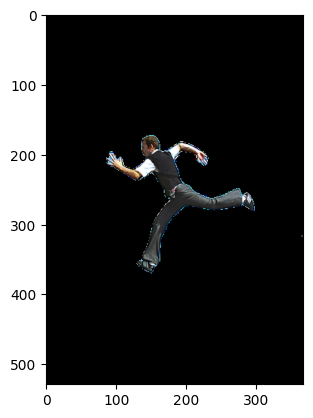

In [221]:
foreground = cv.imread("Assets/foreground.png")
foreground_rgb = cv.cvtColor(foreground, cv.COLOR_BGR2RGB)

plt.imshow(foreground_rgb)
print(foreground.shape)

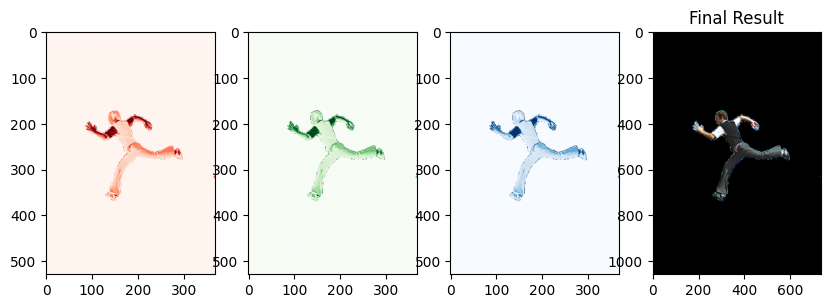

In [222]:
tinggi = foreground.shape[0]
lebar = foreground.shape[1]

blue = foreground[:, :, 0]
green = foreground[:, :, 1]
red = foreground[:, :, 2]

blueBaru = np.zeros((tinggi * 2, lebar * 2), dtype=np.uint8)
greenBaru = np.zeros((tinggi * 2, lebar * 2), dtype=np.uint8)
redBaru = np.zeros((tinggi * 2, lebar * 2), dtype=np.uint8)

for i in range(tinggi * 2):
    for j in range(lebar * 2):

        x = int(i / 2)
        y = int(j / 2)

        blueBaru[i, j] = blue[x, y]
        greenBaru[i, j] = green[x, y]
        redBaru[i, j] = red[x, y]

hasil = np.zeros((tinggi * 2, lebar * 2, 3), dtype=np.uint8)

for i in range(tinggi * 2):
    for j in range(lebar * 2):

        hasil[i, j, 0] = blueBaru[i, j]
        hasil[i, j, 1] = greenBaru[i, j]
        hasil[i, j, 2] = redBaru[i, j]

hasilForeground = np.zeros((tinggi * 2, lebar * 2, 3), dtype=np.uint8)

for i in range(tinggi * 2):
    for j in range(lebar * 2):

        hasilForeground[i, j, 0] = hasil[i, j, 2]
        hasilForeground[i, j, 1] = hasil[i, j, 1]
        hasilForeground[i, j, 2] = hasil[i, j, 0]

plt.figure(figsize=(10, 10))

plt.subplot(1, 4, 1)
plt.imshow(red, cmap='Reds')

plt.subplot(1, 4, 2)
plt.imshow(green, cmap='Greens')

plt.subplot(1, 4, 3)
plt.imshow(blue, cmap='Blues')

plt.subplot(1, 4, 4)
plt.imshow(hasilForeground)
plt.title("Final Result")

plt.show()

(1058, 736, 3)


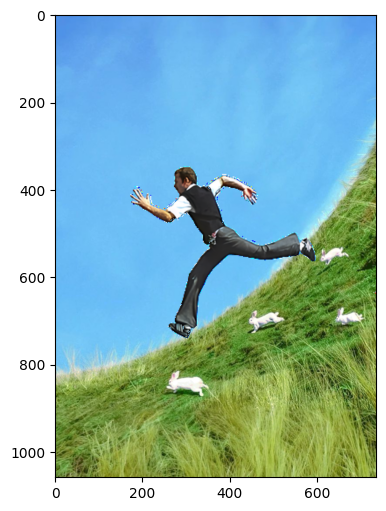

In [223]:
tinggi, lebar = hasilBackground.shape[:2]
gabungan = np.zeros((tinggi, lebar, 3), dtype=np.uint8)

for i in range(tinggi):
    for j in range(lebar):
        if hasilForeground[i, j, 0] > 0 or hasilForeground[i, j, 1] > 0 or hasilForeground[i, j, 2] > 0:
            gabungan[i, j, 0] = hasilForeground[i, j, 0]
            gabungan[i, j, 1] = hasilForeground[i, j, 1]
            gabungan[i, j, 2] = hasilForeground[i, j, 2]
        else:
            gabungan[i, j, 0] = hasilBackground[i, j, 0]
            gabungan[i, j, 1] = hasilBackground[i, j, 1]
            gabungan[i, j, 2] = hasilBackground[i, j, 2]

print(gabungan.shape)

plt.figure(figsize=(6, 6))
plt.imshow(gabungan)
plt.show()

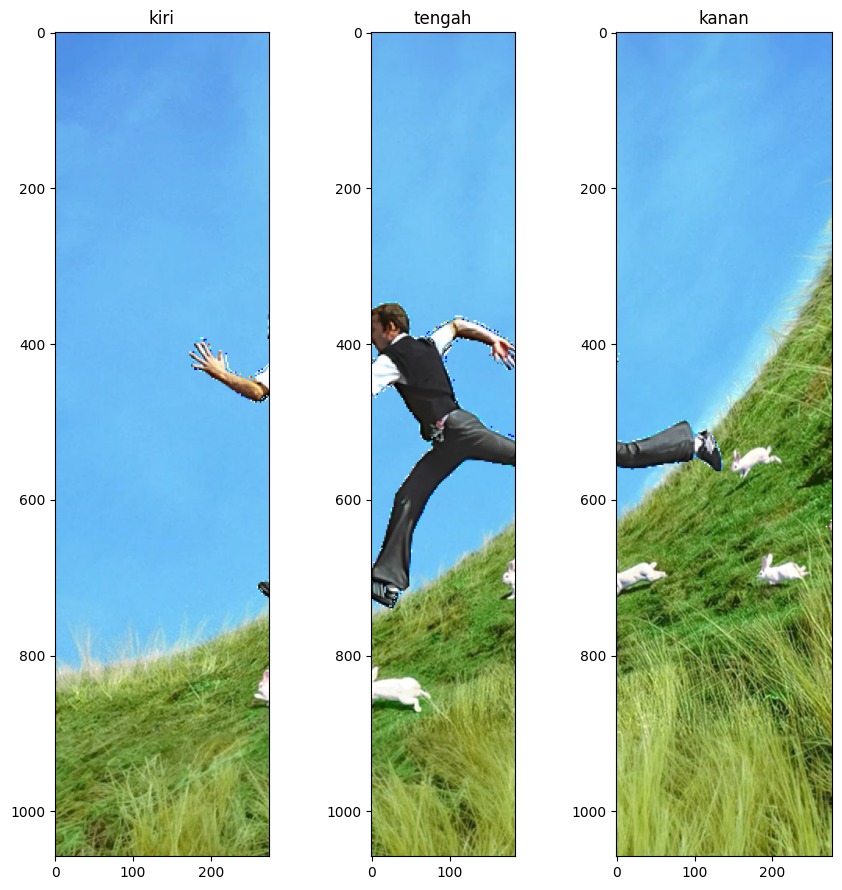

In [224]:
kiri = gabungan[:, :275]
tengah = gabungan[:, 275:459]
kanan = gabungan[:, 459:]

plt.figure(figsize=(9, 9))

plt.subplot(1, 3, 1)
plt.imshow(kiri)
plt.title('kiri')

plt.subplot(1, 3, 2)
plt.imshow(tengah)
plt.title('tengah')

plt.subplot(1, 3, 3)
plt.imshow(kanan)
plt.title('kanan')

plt.tight_layout()
plt.show()

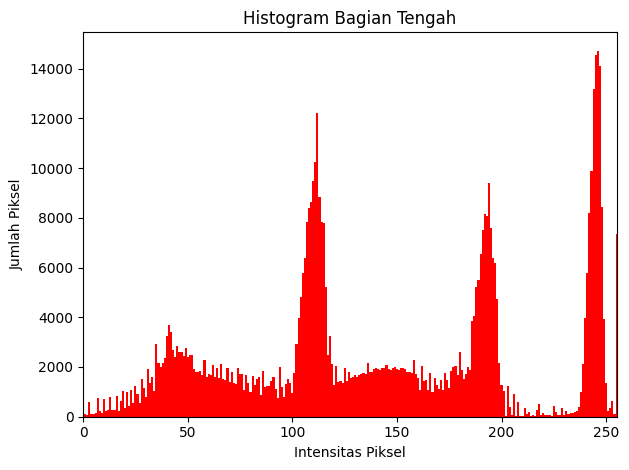

In [225]:
def hitung_histogram_channel(citra):

    histogram = np.zeros(256, dtype=int)

    tinggi = citra.shape[0]
    lebar = citra.shape[1]

    for i in range(tinggi):
        for j in range(lebar):

            blue = citra[i, j, 0]
            green = citra[i, j, 1]
            red = citra[i, j, 2]

            histogram[blue] += 1
            histogram[green] += 1
            histogram[red] += 1

    return histogram

histTengah = hitung_histogram_channel(tengah)

plt.bar(range(256), histTengah, color='red', width=1)
plt.title('Histogram Bagian Tengah')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim([0,255])

plt.tight_layout()
plt.show()

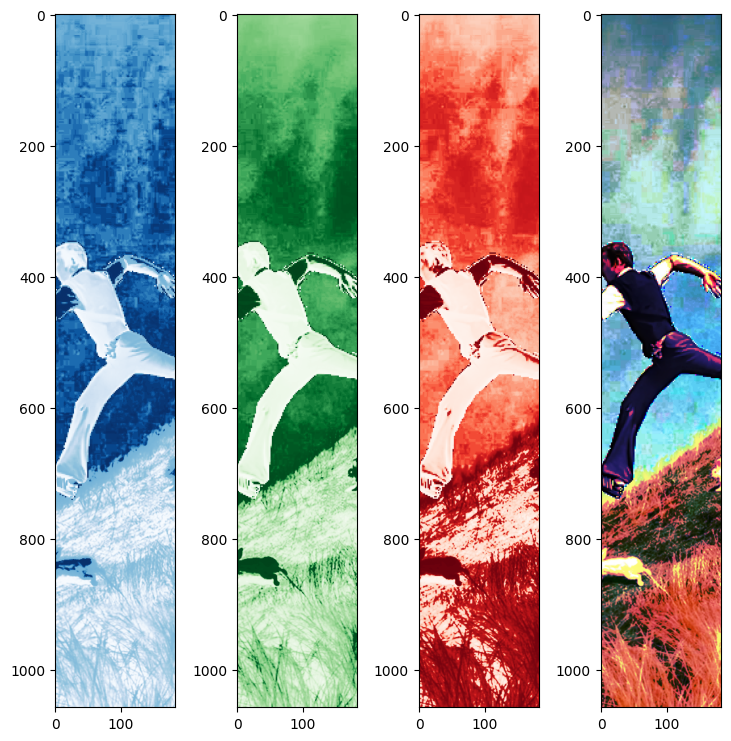

In [226]:
def ekualisasi(citra):
    height, width = citra.shape

    hist = np.zeros(256, dtype=int)

    for i in range(height):
        for j in range(width):
            hist[citra[i, j]] += 1  #menghitung kemunculan intensitas 

    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0] #mengisi nilai awal cdf sesuai dgn nilai intensitas hist

    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + hist[i] #akumulasi hist

    cdf_normal = np.round(cdf * 255 / (height * width)).astype(np.uint8) #cdf normalisasi

    hasil = np.zeros_like(citra, dtype=np.uint8)

    for i in range(height):
        for j in range(width):
            hasil[i, j] = cdf_normal[citra[i, j]] 

    return hasil

tengahRed = tengah[:, :, 0]
tengahGreen = tengah[:, :, 1]
tengahBlue = tengah[:, :, 2]

ekualisasiRed = ekualisasi(tengahRed)
ekualisasiGreen = ekualisasi(tengahGreen)
ekualisasiBlue = ekualisasi(tengahBlue)

tinggi = ekualisasiRed.shape[0]
lebar = ekualisasiRed.shape[1]

hasilEkualisasi = np.zeros((tengah.shape[0], tengah.shape[1], 3), dtype=np.uint8)

for i in range(tinggi):
    for j in range(lebar):
        hasilEkualisasi[i, j, 0] = ekualisasiRed[i, j]
        hasilEkualisasi[i, j, 1] = ekualisasiGreen[i, j]
        hasilEkualisasi[i, j, 2] = ekualisasiBlue[i, j]

plt.figure(figsize=(9, 9))

plt.subplot(1, 4, 1)
plt.imshow(ekualisasiBlue, cmap='Blues')

plt.subplot(1, 4, 2)
plt.imshow(ekualisasiGreen, cmap='Greens')

plt.subplot(1, 4, 3)
plt.imshow(ekualisasiRed, cmap='Reds')

plt.subplot(1, 4, 4)
plt.imshow(hasilEkualisasi)

plt.show()

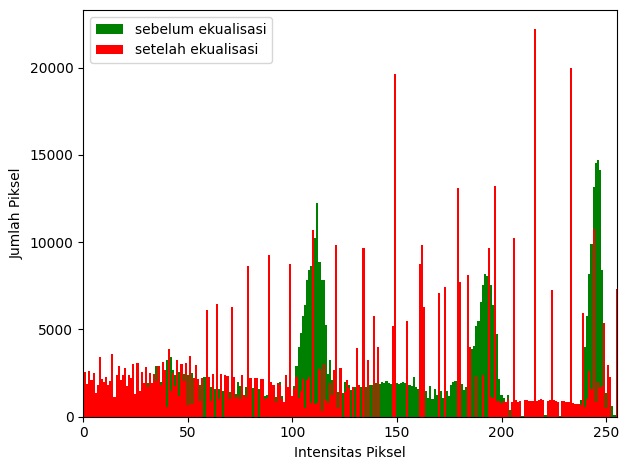

In [227]:
histTengahEku = hitung_histogram_channel(hasilEkualisasi)

plt.bar(range(256), histTengah, color='green', label='sebelum ekualisasi', width=1)
plt.bar(range(256), histTengahEku, color='red', label='setelah ekualisasi',width=1)
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim([0,255])
plt.legend()

plt.tight_layout()
plt.show()

(1058, 275, 3)
(1058, 184, 3)


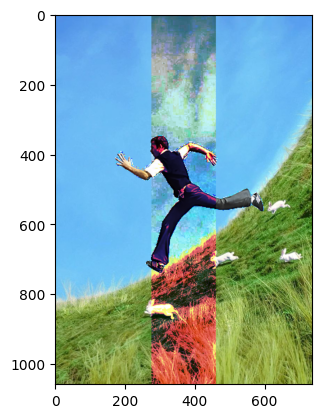

In [228]:
def merge_horizontal(gambar1, gambar2):
    c1, c2 = np.array(gambar1), np.array(gambar2)
    tinggi = max(c1.shape[0], c2.shape[0])
    lebar = c1.shape[1] + c2.shape[1]
    hasil = np.zeros((tinggi, lebar, 3), dtype=c1.dtype)
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1
    hasil[0:c2.shape[0], c1.shape[1]:] = c2
    return hasil

merge1 = merge_horizontal(kiri, hasilEkualisasi)
merge2 = merge_horizontal(merge1, kanan)

plt.imshow(merge2)

print(kiri.shape)
print(hasilEkualisasi.shape)

# Kesimpulan
berdasarkan responsi ini, dapat disimpulkan bahwa melakukan spesifikasi dan ekualisasi bisa dilakukan juga pada citra yang berwarna, tidak hanya grayscale aja. Pada citra berwarna, proses dilakukan dengan memisahkan setiap channel warna yaitu red, green, dan blue, kemudian masing-masing channel diproses secara terpisah sebelum digabungkan kembali menjadi satu citra utuh. hasil intensitas dari citra setelah ekualisasi juga jadi merata. Melalui proses spesifikasi histogram, distribusi intensitas warna pada citra dapat disesuaikan dengan citra target sehingga tampilan warna dan kontras gambar berubah mengikuti karakteristik referensi yang digunakan. Selain itu, proses transformasi geometri juga membantu menyesuaikan ukuran foreground dengan background tanpa menggunakan fungsi resize, sehingga kedua gambar dapat digabungkan dengan baik.